## EVTOL & Passenger arrival time distribution

In [42]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import folium
import math

# eVTOL Stochastic Scheduling - Global Configuration

# Simulation Settings
BASE_PRICE = 0.1482   # Average residential electricity rate in Dallas (PowerChoiceTexas.org, 2025)
M_PEAK = 1.5          # CoServ TOU Rate Sheet: Peak ≈ 20.92¢/kWh
M_SHOULDER = 1.05     # Shoulder multiplier (transitional pricing)
M_OFF = 0.6           # CoServ TOU Rate Sheet: Off-peak ≈ 8.56¢/kWh
# Reference: https://www.powerchoicetexas.org/cities/dallas-electricity-rates , https://www.coserv.com/service/residential/residential-rates/

# eVTOL and Battery Parameters
SOC_MIN = 70.0                      # Minimum required state of charge (%)
BATTERY_CAPACITY = 150.0            # Battery capacity in kWh
CHARGING_RATE = 125                 # Charging power in kW
EVTOL_CAPACITY = 4                  # Maximum passengers per eVTOL
# Reference: Z. Wu, Y. Zhang, Optimal eVTOL charging and passenger scheduling, AIAA Aviation 2020 Forum, 2020.

# Scenario Generation Parameters
N_SCENARIOS = 30                    # Number of demand scenarios generated
TARGET_SCENARIOS = 3                # Number of reduced representative scenarios
HORIZON_MINUTES = 240               # 4-hour simulation horizon (240 minutes total)
BIN_SIZE = 10                       # Each time bin equals 10 minutes

# Model Parameters
M_FACILITIES = 3                    # Number of charging facilities
L_PERIODS = 24                      # Number of 10-minute periods (24 × 10 = 240 min)
LOS = 2                             # Level of Service: maximum waiting time (2 periods = 20 min)

# Randomization Control
SEED = 60                           # Random seed for reproducibility

# Vertiport Network Definition (Hub + 9 Destinations)
vertiports = {
    'Dallas CBD': (32.7767, -96.7970),
    'DFW Airport': (32.8998, -97.0409),
    'Dallas Love Field Airport': (32.84815, -96.85135),
    'Fort Worth City Center': (32.75550, -97.33080),
    'Mesquite Metro Airport': (32.7470, -96.5304),
    'Dallas Executive Airport (RBD)': (32.6810, -96.8690),
    'Denton Municipal Airport': (33.20083, -97.19778),
    'Fort Worth Meacham International Airport': (32.81969, -97.36319),
    'Arlington Municipal Airport': (32.6639, -97.0943),
    'McKinney National Airport': (33.1753, -96.5825)
}

# Haversine Function to Calculate Distance in Miles
def haversine_miles(lat1, lon1, lat2, lon2):
    """Compute great-circle distance between two coordinates in miles."""
    R = 3958.8
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

# Define Hub and Calculate Destination Data
hub_name = 'Dallas CBD'
hub_coord = vertiports[hub_name]
NUM_DESTINATIONS = len(vertiports) - 1

DESTINATION_DATA = {}
for name, coord in vertiports.items():
    if name == hub_name:
        continue
    dist_miles = haversine_miles(hub_coord[0], hub_coord[1], coord[0], coord[1])
    fare = round(20 + 3 * dist_miles, 2)
    DESTINATION_DATA[name] = {"distance": dist_miles, "fare": fare}

# Destination Number and Fare Mapping
destination_map = {i + 1: name for i, name in enumerate(DESTINATION_DATA.keys())}
name_to_number = {name: i for i, name in destination_map.items()}
numbered_fares = {i + 1: DESTINATION_DATA[name]["fare"] for i, name in enumerate(DESTINATION_DATA.keys())}

# Destination Summary Table
print(f"\nNumber of destinations: {NUM_DESTINATIONS}\n")
print("Destination Summary (from Dallas CBD)")
print("No.   Destination                              Miles     Fare ($)")
print("---------------------------------------------------------------")
for num, name in destination_map.items():
    data = DESTINATION_DATA[name]
    print(f"{num:<5} {name:<40} {data['distance']:>8.1f} {data['fare']:>10.2f}")

# Map Visualization
m = folium.Map(location=hub_coord, zoom_start=9)
for name, coord in vertiports.items():
    color = 'red' if name == hub_name else 'blue'
    folium.CircleMarker(location=coord, radius=8, popup=name,
                        color=color, fill=True, fill_color=color).add_to(m)

for name, coord in vertiports.items():
    if name == hub_name:
        continue
    dist_miles = DESTINATION_DATA[name]["distance"]
    fare = DESTINATION_DATA[name]["fare"]
    folium.PolyLine([hub_coord, coord], color='black', weight=2, opacity=0.6,
                    tooltip=f"{name}: {dist_miles:.1f} mi | ${fare:.0f}").add_to(m)

m



Number of destinations: 9

Destination Summary (from Dallas CBD)
No.   Destination                              Miles     Fare ($)
---------------------------------------------------------------
1     DFW Airport                                  16.5      69.55
2     Dallas Love Field Airport                     5.9      37.58
3     Fort Worth City Center                       31.0     113.15
4     Mesquite Metro Airport                       15.6      66.88
5     Dallas Executive Airport (RBD)                7.8      43.48
6     Denton Municipal Airport                     37.4     132.18
7     Fort Worth Meacham International Airport     33.0     119.05
8     Arlington Municipal Airport                  19.0      76.87
9     McKinney National Airport                    30.2     110.65


In [43]:
# ============================================================
# ⚡ Energy Price Function (1-hour version)
# ============================================================
def energy_price_per_kWh(t, base=BASE_PRICE, m_peak=M_PEAK,
                         m_shoulder=M_SHOULDER, m_off=M_OFF):
    """Time-of-Use (TOU) pricing function. t in [0,24). Returns $/kWh."""
    if not (0 <= t < 24):
        raise ValueError("t must be in [0,24)")
    if 16 <= t < 21:                      # 4–9 pm
        return base * m_peak
    elif 0 <= t < 6 or 21 <= t < 24:      # midnight–6 am, 9 pm–midnight
        return base * m_off
    else:                                 # shoulder
        return base * m_shoulder

# ============================================================
# 🚁 eVTOL & Passenger Simulation (Baseline)
# ============================================================
def simulate_evtol_and_passengers(seed=SEED,
                                  soc_min=SOC_MIN,
                                  battery_capacity=BATTERY_CAPACITY,
                                  charging_rate=CHARGING_RATE,
                                  destination_data=DESTINATION_DATA,
                                  plot=True):
    """
    Simulate eVTOL & passenger arrivals over a 240–480 min window.
    Randomly assigns ~60% to 'Fort Worth City Center', rest to others.
    """
    np.random.seed(seed)
    random.seed(seed)

    if destination_data is None or len(destination_data) == 0:
        raise ValueError("destination_data dictionary is required.")

    # 1) Passenger arrivals (minutes)
    passenger_arrivals = np.concatenate([
        np.random.normal(400, 85, 320),
        np.random.normal(1050, 95, 310),
        np.random.normal(800, 250, 220)
    ])

    # 2) eVTOL arrivals (minutes)
    evtol_arrivals = np.concatenate([
        np.random.normal(400, 90, 310),
        np.random.normal(600, 70, 120),
        np.random.normal(800, 80, 120),
        np.random.normal(1000, 60, 220),
        np.random.normal(1200, 70, 60)
    ])

    # Keep within [240, 480)
    passenger_arrivals = passenger_arrivals[(passenger_arrivals >= 240) & (passenger_arrivals < 480)]
    evtol_arrivals = evtol_arrivals[(evtol_arrivals >= 240) & (evtol_arrivals < 480)]

    # 3) SoC
    SoC = {j: random.uniform(20, 60) for j in range(len(evtol_arrivals))}

    # 4) Charging simulation
    charging_cost, charging_periods, finish_period = {}, {}, {}
    for j, arrival_min in enumerate(evtol_arrivals):
        if SoC[j] < soc_min:
            charge_needed = battery_capacity * ((soc_min - SoC[j]) / 100.0)
            hours_to_charge = charge_needed / charging_rate
            periods_to_charge = int(hours_to_charge * 6) + 1
            charging_periods[j] = periods_to_charge

            total_cost = 0.0
            current_time_min = arrival_min
            remaining_periods = periods_to_charge
            while remaining_periods > 0 and current_time_min < 480:
                price = energy_price_per_kWh(current_time_min / 60.0)
                energy_this_period = charging_rate / 6
                total_cost += energy_this_period * price
                current_time_min += 10
                remaining_periods -= 1

            charging_cost[j] = total_cost
            finish_period[j] = current_time_min
        else:
            charging_periods[j] = 0
            finish_period[j] = arrival_min
            charging_cost[j] = 0

    # 5) Passenger destinations & fares (60% random to hub)
    destinations = list(destination_data.keys())
    hub_focus = "Fort Worth City Center"
    if hub_focus not in destinations:
        raise ValueError(f"'{hub_focus}' not present in DESTINATION_DATA.")
    other_dests = [d for d in destinations if d != hub_focus]

    total_passengers = len(passenger_arrivals)
    n_focus = int(total_passengers * 0.6)
    focus_passengers = set(random.sample(range(total_passengers), n_focus)) if total_passengers > 0 else set()

    destination_of_passenger = {}
    for k in range(total_passengers):
        if k in focus_passengers:
            destination_of_passenger[k] = hub_focus
        else:
            destination_of_passenger[k] = random.choice(other_dests) if other_dests else hub_focus

    fare_of_passenger = {
        k: destination_data[destination_of_passenger[k]]["fare"]
        for k in range(total_passengers)
    }

    # 6) Optional plots
    if plot:
        fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        axs[0].hist(passenger_arrivals, bins=24, alpha=0.7, edgecolor='black')
        axs[0].set_ylabel("Passenger Count")
        axs[0].set_title("Passenger Arrivals (10-min bins)")
        axs[0].grid(True, alpha=0.3)

        axs[1].hist(evtol_arrivals, bins=24, alpha=0.7, edgecolor='black')
        axs[1].set_xlabel("Arrival Time (minutes)")
        axs[1].set_ylabel("eVTOL Count")
        axs[1].set_title("eVTOL Arrivals (10-min bins)")
        axs[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "passenger_arrivals": passenger_arrivals,
        "evtol_arrivals": evtol_arrivals,
        "SoC": SoC,
        "charging_periods": charging_periods,
        "finish_charging": finish_period,
        "charging_cost": charging_cost,
        "destinations": destination_of_passenger,  # name → per passenger
        "fares": fare_of_passenger
    }

# ============================================================
# 🧩 Build Per-Bin Destination PMFs from Baseline
# ============================================================
from collections import Counter

def build_bin_destination_pmfs(passenger_arrivals, passenger_dest_names,
                               start_min=240, end_min=480, bin_size=BIN_SIZE,
                               alpha=1.0,                    # Laplace smoothing
                               focus_name="Fort Worth City Center",
                               blend_weight=0.15,            # 0=no blend
                               focus_share_target=0.60):
    """
    Build per-bin categorical PMFs over destinations, with smoothing and
    optional blending toward a global target mix.
    """
    l_periods = (end_min - start_min) // bin_size
    bin_idx = np.clip(((passenger_arrivals - start_min) // bin_size).astype(int), 0, l_periods-1)

    per_bin_counts = [Counter() for _ in range(l_periods)]
    all_dests = set()
    for pid, b in enumerate(bin_idx):
        dname = passenger_dest_names[pid]
        per_bin_counts[b][dname] += 1
        all_dests.add(dname)

    global_counts = Counter(passenger_dest_names.values())
    total_global = sum(global_counts.values())
    global_p = {d: (global_counts[d] / total_global) if total_global > 0 else 0.0 for d in all_dests}

    other_dests = [d for d in all_dests if d != focus_name]
    if other_dests:
        rem = 1.0 - focus_share_target
        p_target = {d: rem/len(other_dests) for d in other_dests}
        p_target[focus_name] = focus_share_target
    else:
        p_target = {focus_name: 1.0}

    pmfs = []
    for t in range(l_periods):
        counts = per_bin_counts[t]
        total = sum(counts.values())

        # Laplace-style smoothing with global prior
        pmf = {}
        for d in all_dests:
            prior = global_p.get(d, 1.0/len(all_dests))
            pmf[d] = (counts.get(d, 0) + alpha * prior) / (total + alpha)

        # Optional blend toward target mix
        if blend_weight > 0:
            for d in pmf:
                pmf[d] = (1 - blend_weight) * pmf[d] + blend_weight * p_target.get(d, 0.0)

        # Normalize
        s = sum(pmf.values())
        if s > 0:
            for d in pmf:
                pmf[d] /= s

        pmfs.append(pmf)

    return pmfs, sorted(all_dests)


Destination Number Mapping:
----------------------------------------------------------------------
 1. DFW Airport                                   $  69.55
 2. Dallas Love Field Airport                     $  37.58
 3. Fort Worth City Center                        $ 113.15
 4. Mesquite Metro Airport                        $  66.88
 5. Dallas Executive Airport (RBD)                $  43.48
 6. Denton Municipal Airport                      $ 132.18
 7. Fort Worth Meacham International Airport      $ 119.05
 8. Arlington Municipal Airport                   $  76.87
 9. McKinney National Airport                     $ 110.65
----------------------------------------------------------------------


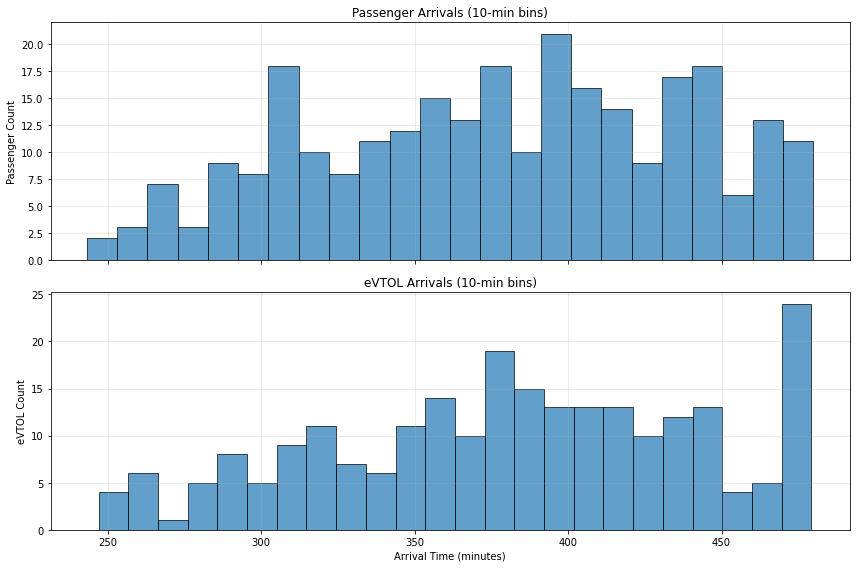


SIMULATION SUMMARY
Passengers generated: 272
eVTOLs generated:     238

eVTOL SoC and Charging Details:
  eVTOL   0: SoC= 32.3%, ChargePeriods= 3, Cost=$  9.73
  eVTOL   1: SoC= 43.1%, ChargePeriods= 2, Cost=$  3.70
  eVTOL   2: SoC= 30.6%, ChargePeriods= 3, Cost=$  6.95
  eVTOL   3: SoC= 52.3%, ChargePeriods= 2, Cost=$  6.48
  eVTOL   4: SoC= 38.7%, ChargePeriods= 3, Cost=$  8.34
  eVTOL   5: SoC= 33.3%, ChargePeriods= 3, Cost=$  3.24
  eVTOL   6: SoC= 55.9%, ChargePeriods= 2, Cost=$  3.70
  eVTOL   7: SoC= 51.7%, ChargePeriods= 2, Cost=$  3.70
  eVTOL   8: SoC= 54.4%, ChargePeriods= 2, Cost=$  6.48
  eVTOL   9: SoC= 46.6%, ChargePeriods= 2, Cost=$  5.09
  eVTOL  10: SoC= 27.4%, ChargePeriods= 4, Cost=$  7.41
  eVTOL  11: SoC= 35.6%, ChargePeriods= 3, Cost=$  8.34
  eVTOL  12: SoC= 29.6%, ChargePeriods= 3, Cost=$  6.95
  eVTOL  13: SoC= 51.7%, ChargePeriods= 2, Cost=$  6.48
  eVTOL  14: SoC= 20.4%, ChargePeriods= 4, Cost=$ 12.97
  eVTOL  15: SoC= 51.6%, ChargePeriods= 2, Cost=$  3.70

In [44]:
# ============================================================
# 🧭 Main Execution
# ============================================================
if __name__ == "__main__":
    """
    Entry point for simulation stage.
    Generates and visualizes base passenger & eVTOL arrival data
    using numbered destinations.
    """

    # ------------------------------------------------------------
    # 🔢 Create Numbered Destination Mapping
    # ------------------------------------------------------------
    destination_map = {i + 1: name for i, name in enumerate(DESTINATION_DATA.keys())}
    numbered_fares = {i + 1: DESTINATION_DATA[name]["fare"] for i, name in enumerate(DESTINATION_DATA.keys())}

    print("\nDestination Number Mapping:")
    print("-" * 70)
    for num, name in destination_map.items():
        print(f"{num:2d}. {name:<45} ${numbered_fares[num]:>7.2f}")
    print("-" * 70)

    # ------------------------------------------------------------
    # 🚀 Run Base Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA,
        plot=True
    )

    # Convert destination names in results to numeric IDs
    name_to_id = {v: k for k, v in destination_map.items()}
    results["destinations_num"] = {pid: name_to_id[dest] for pid, dest in results["destinations"].items()}

    # ------------------------------------------------------------
    # 📊 Display Summary
    # ------------------------------------------------------------
    print("\n" + "=" * 70)
    print("SIMULATION SUMMARY")
    print("=" * 70)
    print(f"Passengers generated: {len(results['passenger_arrivals'])}")
    print(f"eVTOLs generated:     {len(results['evtol_arrivals'])}\n")

    print("eVTOL SoC and Charging Details:")
    for j, soc in results["SoC"].items():
        print(f"  eVTOL {j:3d}: SoC={soc:5.1f}%, "
              f"ChargePeriods={results['charging_periods'][j]:2d}, "
              f"Cost=${results['charging_cost'][j]:6.2f}")

    print("\nPassenger Destinations & Fares (By Number):")
    for k, dest_id in results["destinations_num"].items():
        print(f"  Passenger {k:3d}: Destination {dest_id:2d} "
              f"({destination_map[dest_id]:<35}) Fare=${results['fares'][k]:6.2f}")
'''
    # ------------------------------------------------------------
    # 📈 Passenger Distribution Summary
    # ------------------------------------------------------------
    from collections import Counter
    print("\n" + "=" * 70)
    print("PASSENGER DISTRIBUTION SUMMARY (By Destination Number)")
    print("=" * 70)
    dest_count = Counter(results["destinations_num"].values())
    total = len(results["destinations_num"])
    for dest_id, count in dest_count.items():
        pct = (count / total) * 100
        print(f"Destination {dest_id:2d}: {destination_map[dest_id]:<35} "
              f"{count:5d} passengers ({pct:5.1f}%)")
    print("=" * 70)
'''

# ------------------------------------------------------------
# ⏱ Detailed Passenger Arrival Information
# ------------------------------------------------------------
print("\nDETAILED PASSENGER ARRIVALS (with Destination & Fare)")
print("-" * 70)
for k, dest_id in results["destinations_num"].items():
    arrival_time = results["passenger_arrivals"][k]
    fare = results["fares"][k]
    print(f"Passenger {k:3d}: Arrived at {arrival_time:7.2f} min | "
          f"Destination {dest_id:2d} ({destination_map[dest_id]:<30}) | "
          f"Fare: ${fare:6.2f}")
print("=" * 70)


## Joint Demand Scenario Generation with NHPP

In [45]:
# Joint Demand Scenario Generator (NHPP + Bin PMFs)
def generate_joint_demand_scenarios(passenger_arrivals,
                                    evtol_arrivals,
                                    destination_data,
                                    bin_pmfs,
                                    n_scenarios=N_SCENARIOS,
                                    horizon_minutes=HORIZON_MINUTES,
                                    bin_size=BIN_SIZE,
                                    plot=True):
    """
    Generate multiple joint demand scenarios for passenger arrivals,
    eVTOL availability, and destination distributions using a 
    Nonhomogeneous Poisson Process (NHPP) framework.

    Parameters
    ----------
    passenger_arrivals : array-like
        Baseline passenger arrival times (in minutes).
    evtol_arrivals : array-like
        Baseline eVTOL arrival times (in minutes).
    destination_data : dict
        Dictionary containing destination attributes (distance, fare, etc.).
    bin_pmfs : list of dict
        Per-bin categorical probability mass functions (PMFs) over destinations.
    n_scenarios : int
        Number of stochastic scenarios to generate.
    horizon_minutes : int
        Total simulation horizon in minutes (default = 240 for 4 hours).
    bin_size : int
        Time resolution per bin (default = 10 minutes).
    plot : bool
        Whether to visualize baseline rate curves.

    Returns
    -------
    scenarios : list of dict
        A list of scenario dictionaries, each containing:
            - a_t : simulated passenger arrivals per bin
            - e_t : simulated eVTOL arrivals per bin
            - total_passengers : total passengers in scenario
            - total_evtols : total eVTOLs in scenario
            - destination_counts : per-destination passenger count
            - passenger_destinations : passenger → destination mapping
            - passenger_fares : passenger → fare mapping
    """

    # ------------------------------------------------------------
    # 1. Define Time Discretization
    # ------------------------------------------------------------
    start_min, end_min = 240, 480
    l_periods = (end_min - start_min) // bin_size
    bin_edges = np.linspace(start_min, end_min, l_periods + 1)
    time_periods = np.arange(1, l_periods + 1)

    # ------------------------------------------------------------
    # 2. Build Baseline Histograms and Smooth Arrival Rates
    # ------------------------------------------------------------
    # Count baseline arrivals per bin
    passenger_hist, _ = np.histogram(passenger_arrivals, bins=bin_edges)
    evtol_hist, _ = np.histogram(evtol_arrivals, bins=bin_edges)

    # Smooth baseline rates using Gaussian filter
    f_a = gaussian_filter1d(passenger_hist.astype(float), sigma=2)
    f_e = gaussian_filter1d(evtol_hist.astype(float), sigma=2)

    # Compute residual variance for stochastic noise estimation
    residuals_a = passenger_hist - f_a
    residuals_e = evtol_hist - f_e
    sigma_epsilon_sq = min(np.var(residuals_a), np.var(residuals_e))

    # ------------------------------------------------------------
    # 3. Generate Multiple NHPP-Based Scenarios
    # ------------------------------------------------------------
    scenarios = []
    for scenario_id in range(n_scenarios):

        # Add Gaussian noise to create stochastic rate realizations
        epsilon_t = np.random.normal(0, np.sqrt(sigma_epsilon_sq), l_periods)

        # Ensure rates remain nonnegative
        lambda_a_omega = np.maximum(f_a + epsilon_t, 0)
        lambda_e_omega = np.maximum(f_e + epsilon_t, 0)

        # Sample arrivals per bin using Poisson draws
        a_t_omega = np.random.poisson(lambda_a_omega)
        e_t_omega = np.random.poisson(lambda_e_omega)

        # --------------------------------------------------------
        # 4. Destination Sampling for Each Passenger Arrival Bin
        # --------------------------------------------------------
        passenger_destinations, passenger_fares = {}, {}
        pid = 0

        for t in range(l_periods):
            n = int(a_t_omega[t])
            if n <= 0:
                continue

            # Get PMF for this time bin
            pmf = bin_pmfs[t]
            dnames = list(pmf.keys())
            probs = np.array([pmf[d] for d in dnames], dtype=float)
            probs /= probs.sum() if probs.sum() > 0 else 1.0

            # Sample destinations according to bin PMF
            choices = np.random.choice(dnames, size=n, p=probs)
            for dname in choices:
                passenger_destinations[pid] = dname
                passenger_fares[pid] = destination_data[dname]["fare"]
                pid += 1

        # Summarize destination counts for this scenario
        dest_counts = Counter(passenger_destinations.values())

        # Store all scenario data
        scenarios.append({
            "id": scenario_id,
            "a_t": a_t_omega,
            "e_t": e_t_omega,
            "total_passengers": int(np.sum(a_t_omega)),
            "total_evtols": int(np.sum(e_t_omega)),
            "destination_counts": dict(dest_counts),
            "passenger_destinations": passenger_destinations,
            "passenger_fares": passenger_fares
        })

    # ------------------------------------------------------------
    # 5. Optional Visualization of Smoothed Baseline Rates
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(time_periods, f_a, "o-", label="Baseline Passenger Rate")
        plt.plot(time_periods, f_e, "s-", label="Baseline eVTOL Rate")
        plt.title("Baseline Arrival Rates (Smoothed, 240–480 min)")
        plt.xlabel("Time Period (10-min bins)")
        plt.ylabel("Expected Arrivals per Bin")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return scenarios


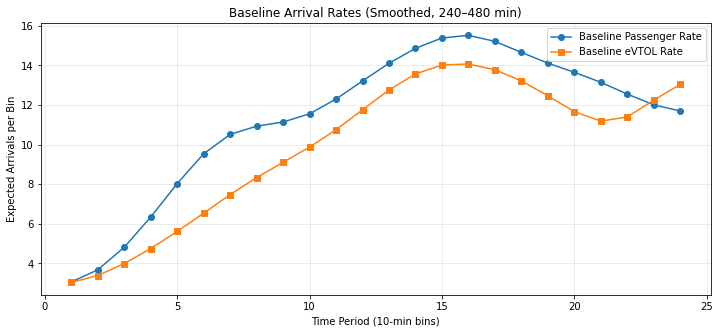


📊 JOINT DEMAND SCENARIO GENERATION SUMMARY
Scenarios generated:      30
Time bins per scenario:   24
Average passengers/scenario: 271.13
Average eVTOLs/scenario:     241.80

Destination Breakdown – Scenario 0:
  Fort Worth City Center                     160 passengers ( 62.5%)
  Fort Worth Meacham International Airport    14 passengers (  5.5%)
  Mesquite Metro Airport                      11 passengers (  4.3%)
  Dallas Love Field Airport                   11 passengers (  4.3%)
  Dallas Executive Airport (RBD)              15 passengers (  5.9%)
  McKinney National Airport                    9 passengers (  3.5%)
  Denton Municipal Airport                    11 passengers (  4.3%)
  DFW Airport                                 10 passengers (  3.9%)
  Arlington Municipal Airport                 15 passengers (  5.9%)

Detailed Passenger Arrivals (Baseline, first 15):
  Passenger   0:  321.65 min | Fort Worth City Center              | Fare $113.15
  Passenger   1:  350.16 min | Fort

In [46]:
# Main Execution – Scenario Generation
if __name__ == "__main__":
    """
    Main pipeline for generating stochastic passenger and eVTOL demand scenarios.
    This stage integrates:
      (1) Baseline simulation
      (2) Per-bin destination PMF construction
      (3) NHPP-based scenario generation
      (4) Summary visualization and reporting
    """

    # ------------------------------------------------------------
    # 1. Baseline Simulation
    # ------------------------------------------------------------
    # Generate synthetic passenger and eVTOL arrivals for the base case.
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA,
        plot=False     # Set True to visualize baseline histograms
    )

    # ------------------------------------------------------------
    # 2. Build Per-Bin Destination Probability Distributions
    # ------------------------------------------------------------
    # Estimate per-bin (10-min interval) categorical distributions of passenger
    # destinations, with optional Laplace smoothing and blending toward a global target.
    bin_pmfs, _ = build_bin_destination_pmfs(
        passenger_arrivals=results["passenger_arrivals"],
        passenger_dest_names=results["destinations"],
        start_min=240, end_min=480, bin_size=BIN_SIZE,
        alpha=1.0,
        focus_name="Fort Worth City Center",
        blend_weight=0.15,
        focus_share_target=0.60
    )

    # ------------------------------------------------------------
    # 3. Generate Stochastic Demand Scenarios
    # ------------------------------------------------------------
    # Use the NHPP-based model to generate multiple joint passenger-eVTOL
    # scenarios that replicate baseline arrival dynamics and destination mixes.
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        destination_data=DESTINATION_DATA,
        bin_pmfs=bin_pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=True
    )

    # ------------------------------------------------------------
    # 4. Scenario Summary and Diagnostics
    # ------------------------------------------------------------
    print("\n" + "=" * 90)
    print("📊 JOINT DEMAND SCENARIO GENERATION SUMMARY")
    print("=" * 90)
    print(f"Scenarios generated:      {len(scenarios)}")
    print(f"Time bins per scenario:   {HORIZON_MINUTES // BIN_SIZE}")
    print(f"Average passengers/scenario: {np.mean([s['total_passengers'] for s in scenarios]):.2f}")
    print(f"Average eVTOLs/scenario:     {np.mean([s['total_evtols'] for s in scenarios]):.2f}")
    print("=" * 90)

    # ------------------------------------------------------------
    # 5. Destination Breakdown for First Scenario
    # ------------------------------------------------------------
    # Displays how passengers are distributed across destinations in the first scenario.
    s0 = scenarios[0]
    total0 = s0["total_passengers"] if s0["total_passengers"] > 0 else 1
    print("\nDestination Breakdown – Scenario 0:")
    for dest, cnt in s0["destination_counts"].items():
        pct = 100 * cnt / total0
        print(f"  {dest:<40} {cnt:5d} passengers ({pct:5.1f}%)")
    print("=" * 90)

    # ------------------------------------------------------------
    # 6. Baseline Passenger Snapshot (Diagnostic)
    # ------------------------------------------------------------
    # Prints the first 15 baseline passengers with their assigned destination and fare.
    print("\nDetailed Passenger Arrivals (Baseline, first 15):")
    for k in range(min(15, len(results['passenger_arrivals']))):
        dname = results["destinations"][k]
        fare = results["fares"][k]
        at = results["passenger_arrivals"][k]
        print(f"  Passenger {k:3d}: {at:7.2f} min | {dname:<35} | Fare ${fare:6.2f}")


## Scenario Reduction via Backward Selection


In [47]:
# ============================================================
# 🔻 Scenario Reduction with eVTOL Filtering (Backward Selection)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Backward Scenario Reduction with eVTOL Constraint
# ------------------------------------------------------------
def scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        plot=True):
    """
    Perform backward scenario reduction while ensuring that
    all selected scenarios contain at least one eVTOL event.

    This algorithm maintains scenario diversity using a
    pairwise Euclidean distance metric over feature vectors
    (combined passenger and eVTOL time series), while
    eliminating the least representative scenarios iteratively.

    Parameters
    ----------
    scenarios : list of dict
        Full set of generated scenarios from
        `generate_joint_demand_scenarios()`.
    target_size : int, default=TARGET_SCENARIOS
        Desired number of representative (reduced) scenarios.
    plot : bool, default=True
        Whether to visualize reduction results (optional diagnostics).

    Returns
    -------
    reduced_scenarios : list of dict
        Reduced scenario set with:
            - normalized probabilities
            - preserved diversity in time profiles
            - no scenarios with zero eVTOL presence
    """

    # ------------------------------------------------------------
    # 1. Filter Scenarios: Ensure at least one eVTOL present
    # ------------------------------------------------------------
    scenarios_with_evtols = [s for s in scenarios if s['total_evtols'] > 0]

    # If fewer valid scenarios than target, keep top by eVTOL count
    if len(scenarios_with_evtols) < target_size:
        scenarios_sorted = sorted(scenarios, key=lambda x: x['total_evtols'], reverse=True)
        scenarios_with_evtols = scenarios_sorted[:target_size]

    # ------------------------------------------------------------
    # 2. Initialize Probabilities & Feature Vectors
    # ------------------------------------------------------------
    n_original = len(scenarios_with_evtols)

    for scenario in scenarios_with_evtols:
        # Assign uniform initial probability
        scenario['probability'] = 1.0 / n_original
        # Build concatenated feature vector of passenger + eVTOL time series
        scenario['feature_vector'] = np.concatenate([scenario['a_t'], scenario['e_t']])

    # Working copy for iterative reduction
    working_scenarios = scenarios_with_evtols.copy()

    # ------------------------------------------------------------
    # 3. Backward Reduction Loop
    # ------------------------------------------------------------
    while len(working_scenarios) > target_size:
        n_current = len(working_scenarios)
        distances = np.zeros((n_current, n_current))

        # Compute pairwise Euclidean distances among all scenario vectors
        for i in range(n_current):
            for j in range(i + 1, n_current):
                dist = np.linalg.norm(
                    working_scenarios[i]['feature_vector'] -
                    working_scenarios[j]['feature_vector']
                )
                distances[i, j] = distances[j, i] = dist

        # Identify scenario with smallest “cost” (least representative)
        min_cost, remove_idx, nearest_neighbor = float('inf'), None, None
        for i in range(n_current):
            mask = np.ones(n_current, dtype=bool)
            mask[i] = False
            min_dist = np.min(distances[i, mask])
            cost = working_scenarios[i]['probability'] * min_dist

            if cost < min_cost:
                min_cost = cost
                remove_idx = i
                nearest_neighbor = np.argmin([
                    distances[i, j] if j != i else float('inf')
                    for j in range(n_current)
                ])

        # Transfer probability to nearest scenario, then remove weakest one
        working_scenarios[nearest_neighbor]['probability'] += \
            working_scenarios[remove_idx]['probability']
        _ = working_scenarios.pop(remove_idx)

    # ------------------------------------------------------------
    # 4. Normalize Final Probabilities
    # ------------------------------------------------------------
    total_prob = sum(s['probability'] for s in working_scenarios)
    for s in working_scenarios:
        s['probability'] /= total_prob

    # ------------------------------------------------------------
    # 5. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        l_periods = len(scenarios[0]['a_t'])
        time_periods = np.arange(1, l_periods + 1)
        colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle("Reduced Scenario Set Analysis", fontsize=16, fontweight="bold")

        # (a) Passenger arrival comparison
        for i, s in enumerate(working_scenarios):
            axes[0, 0].plot(time_periods, s['a_t'], 'o-',
                            label=f"Scenario {s['id']+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 0].set_title("Passenger Arrivals per Time Period")
        axes[0, 0].set_xlabel("Time Period (10-min bins)")
        axes[0, 0].set_ylabel("Passenger Count")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # (b) eVTOL arrival comparison
        for i, s in enumerate(working_scenarios):
            axes[0, 1].plot(time_periods, s['e_t'], 's-',
                            label=f"Scenario {s['id']+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 1].set_title("eVTOL Arrivals per Time Period")
        axes[0, 1].set_xlabel("Time Period (10-min bins)")
        axes[0, 1].set_ylabel("eVTOL Count")
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # (c) Scenario probabilities visualization
        labels = [f"Scenario {s['id']+1}" for s in working_scenarios]
        probs = [s['probability'] for s in working_scenarios]
        bars = axes[1, 0].bar(labels, probs,
                              color=colors[:len(working_scenarios)], alpha=0.7)
        axes[1, 0].set_title("Scenario Probabilities")
        axes[1, 0].set_ylabel("Probability")
        axes[1, 0].grid(True, alpha=0.3)
        for bar, prob in zip(bars, probs):
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                            f"{prob:.2f}", ha="center", fontweight="bold")

        # (d) Average comparison: Original vs Reduced
        orig_p = [s['total_passengers'] for s in scenarios if s['total_evtols'] > 0]
        orig_e = [s['total_evtols'] for s in scenarios if s['total_evtols'] > 0]
        red_p = [s['total_passengers'] for s in working_scenarios]
        red_e = [s['total_evtols'] for s in working_scenarios]

        x = np.arange(2)
        w = 0.35
        axes[1, 1].bar(x - w/2, [np.mean(orig_p), np.mean(orig_e)], w,
                       label="Original Avg", alpha=0.6)
        axes[1, 1].bar(x + w/2, [np.mean(red_p), np.mean(red_e)], w,
                       label="Reduced Avg", alpha=0.8)
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(["Passengers", "eVTOLs"])
        axes[1, 1].set_title("Original vs Reduced Scenarios")
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # 6. Return Reduced Scenario Set
    # ------------------------------------------------------------
    return working_scenarios


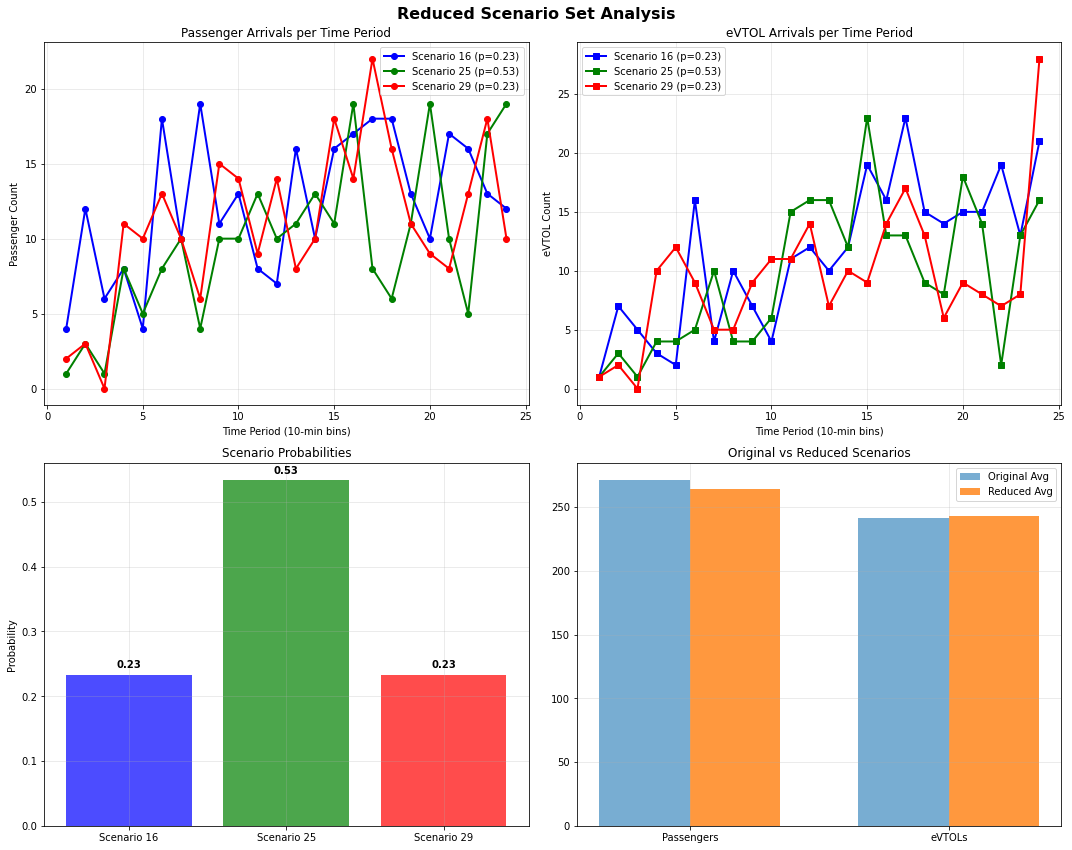


🔻 SCENARIO REDUCTION SUMMARY
Initial Scenarios: 30
Reduced to:        3 scenarios

Final Scenario Probabilities:
  Scenario 16  → p = 0.233
  Scenario 25  → p = 0.533
  Scenario 29  → p = 0.233

Average Total Passengers (Reduced): 264.00
Average Total eVTOLs (Reduced):    243.00
Average Empirical Correlation (Reduced): [N/A – not computed]


In [48]:
# ============================================================
# 🧭 Main Execution – Scenario Reduction Pipeline
# ============================================================
if __name__ == "__main__":
    """
    Full pipeline for stochastic eVTOL scenario generation and reduction.

    Workflow:
      1. Baseline Simulation
      2. Joint Passenger–eVTOL Scenario Generation (NHPP-based)
      3. Backward Scenario Reduction with eVTOL Filtering
      4. Summary Reporting & Diagnostics
    """

    # ------------------------------------------------------------
    # 1. Baseline Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA,
        plot=False
    )

    # ------------------------------------------------------------
    # 2. Generate Initial Joint Demand Scenarios
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        destination_data=DESTINATION_DATA,
        bin_pmfs=bin_pmfs,                    # can be built if PMF modeling included earlier
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ------------------------------------------------------------
    # 3. Apply Backward Scenario Reduction (eVTOL Filtering)
    # ------------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=True
    )

    # ------------------------------------------------------------
    # 4. Summary Report
    # ------------------------------------------------------------
    print("\n" + "=" * 90)
    print("🔻 SCENARIO REDUCTION SUMMARY")
    print("=" * 90)
    print(f"Initial Scenarios: {len(scenarios)}")
    print(f"Reduced to:        {len(reduced_scenarios)} scenarios\n")

    # Probabilities of retained scenarios
    print("Final Scenario Probabilities:")
    for s in reduced_scenarios:
        print(f"  Scenario {s['id']+1:<3} → p = {s['probability']:.3f}")

    # Compute aggregate statistics
    avg_pass = np.mean([s['total_passengers'] for s in reduced_scenarios])
    avg_evtol = np.mean([s['total_evtols'] for s in reduced_scenarios])

    print("\nAverage Total Passengers (Reduced): "
          f"{avg_pass:.2f}")
    print("Average Total eVTOLs (Reduced):    "
          f"{avg_evtol:.2f}")

    # Safely handle missing correlation field
    if all('empirical_corr' in s for s in reduced_scenarios):
        avg_corr = np.mean([s['empirical_corr'] for s in reduced_scenarios])
        print(f"Average Empirical Correlation (Reduced): {avg_corr:.3f}")
    else:
        print("Average Empirical Correlation (Reduced): [N/A – not computed]")

    print("=" * 90)




## Conditional Sampling of State of Charge (SoC)

In [49]:
# ============================================================
# 🔋 Conditional SoC Sampling per eVTOL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Conditional Sampling of SoC based on Passenger Load Ratios
# ------------------------------------------------------------
def conditional_soc_sampling_per_evtol(
        reduced_scenarios,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        plot=False):
    """
    Perform conditional sampling of State of Charge (SoC) for each eVTOL
    based on per-period passenger-to-eVTOL load ratios.

    The model assumes that heavier demand (higher passenger-to-eVTOL ratio)
    corresponds to lower mean SoC and higher SoC variance.

    SoC samples are constrained to the operational range [20%, 60%].

    Parameters
    ----------
    reduced_scenarios : list[dict]
        Scenario set reduced by `scenario_reduction_backward_with_evtol_filter()`.
    s_base : float, default=50
        Base mean SoC when load ratio = 0 (midpoint of 20–60 range).
    k : float, default=12
        Scaling coefficient determining how quickly mean SoC drops as load ratio increases.
    sigma_base : float, default=3
        Baseline standard deviation for SoC sampling.
    sigma_scale : float, default=5
        Scale of variance growth with load ratio.
    plot : bool, default=False
        If True, displays SoC histograms across scenarios.

    Returns
    -------
    reduced_scenarios : list[dict]
        Updated scenario list with additional fields:
            - 'rho_t_omega'              → array of per-period load ratios
            - 'evtol_socs'              → dict {eVTOL_ID: sampled SoC}
            - 'evtol_arrival_periods'   → dict {eVTOL_ID: arrival period index}
            - 'total_evtols_count'      → total eVTOLs in scenario
            - 'avg_load_ratio'          → mean passenger-to-eVTOL ratio across horizon
    """

    # ------------------------------------------------------------
    # 1. Iterate through Reduced Scenarios
    # ------------------------------------------------------------
    for scenario in reduced_scenarios:
        a_t_omega = scenario['a_t']  # Passenger arrivals per time period
        e_t_omega = scenario['e_t']  # eVTOL arrivals per time period

        # ------------------------------------------------------------
        # 2. Compute Load Ratios per Period (ρ_t_ω)
        # ------------------------------------------------------------
        rho_t_omega = np.zeros_like(a_t_omega, dtype=float)
        for t in range(len(a_t_omega)):
            if e_t_omega[t] > 0:
                rho_t_omega[t] = a_t_omega[t] / e_t_omega[t]
            else:
                # Handle zero-eVTOL periods via local interpolation or carry-forward
                if 0 < t < len(a_t_omega) - 1:
                    rho_t_omega[t] = (rho_t_omega[t - 1] + rho_t_omega[t + 1]) / 2
                elif t > 0:
                    rho_t_omega[t] = rho_t_omega[t - 1]
                else:
                    rho_t_omega[t] = rho_t_omega[t + 1] if len(a_t_omega) > 1 else 1.0

        evtol_socs = {}
        evtol_arrival_periods = {}
        evtol_count = 0

        # ------------------------------------------------------------
        # 3. Sample SoC for Each eVTOL
        # ------------------------------------------------------------
        for t in range(len(e_t_omega)):
            for _ in range(e_t_omega[t]):
                evtol_id = evtol_count
                evtol_arrival_periods[evtol_id] = t + 1  # 1-based index

                load_ratio = rho_t_omega[t]
                mu_s = s_base - k * load_ratio
                sigma_s = sigma_base + sigma_scale * load_ratio

                # Bound the mean and std deviation to keep SoC realistic
                mu_s = np.clip(mu_s, 25, 55)
                sigma_s = np.clip(sigma_s, 2, 8)

                # Re-sample until a valid SoC within [20, 60] is drawn
                sampled = False
                while not sampled:
                    soc_sample = np.random.normal(mu_s, sigma_s)
                    if 20 <= soc_sample <= 60:
                        evtol_socs[evtol_id] = soc_sample
                        sampled = True

                evtol_count += 1

        # ------------------------------------------------------------
        # 4. Store Updated Scenario Data
        # ------------------------------------------------------------
        scenario['rho_t_omega'] = rho_t_omega
        scenario['evtol_socs'] = evtol_socs
        scenario['evtol_arrival_periods'] = evtol_arrival_periods
        scenario['total_evtols_count'] = evtol_count
        scenario['avg_load_ratio'] = np.mean(rho_t_omega)

    # ------------------------------------------------------------
    # 5. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(12, 6))
        for scenario in reduced_scenarios:
            socs = list(scenario['evtol_socs'].values())
            plt.hist(socs, bins=8, alpha=0.6, edgecolor="black",
                     label=f"Scenario {scenario['id'] + 1}")
        plt.title("State of Charge (SoC) Distribution Across Reduced Scenarios")
        plt.xlabel("State of Charge (%)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # ------------------------------------------------------------
    # 6. Return Updated Scenario Set
    # ------------------------------------------------------------
    return reduced_scenarios


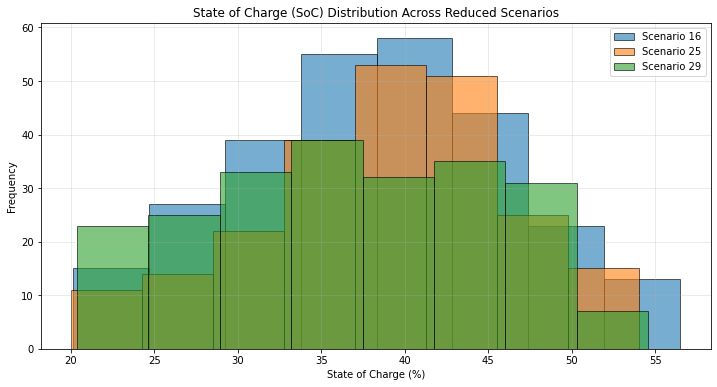


🔋 CONDITIONAL STATE-OF-CHARGE (SoC) SAMPLING SUMMARY
Reduced Scenarios Evaluated: 3

Scenario 16:
  • Total eVTOLs:       274
  • Avg Load Ratio:     1.45
  • SoC Range:          20.1% – 56.5%
  • Mean SoC:           38.2%
  • Std Dev (SoC):      8.05

Scenario 25:
  • Total eVTOLs:       230
  • Avg Load Ratio:     1.19
  • SoC Range:          20.0% – 54.0%
  • Mean SoC:           38.8%
  • Std Dev (SoC):      7.51

Scenario 29:
  • Total eVTOLs:       225
  • Avg Load Ratio:     1.31
  • SoC Range:          20.3% – 54.6%
  • Mean SoC:           36.7%
  • Std Dev (SoC):      8.51



In [50]:
# ============================================================
# 🧭 Main Execution – Conditional SoC Sampling per eVTOL
# ============================================================
if __name__ == "__main__":
    """
    Full pipeline for end-to-end stochastic eVTOL analysis:
      1. Baseline Simulation
      2. Joint Passenger–eVTOL Scenario Generation (NHPP-based)
      3. Backward Scenario Reduction with eVTOL Filtering
      4. Conditional State-of-Charge (SoC) Sampling per eVTOL
      5. Summary Diagnostics and Reporting
    """

    # ------------------------------------------------------------
    # 1. Baseline Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA,
        plot=False
    )

    # ------------------------------------------------------------
    # 2. Generate Joint Demand Scenarios
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        destination_data=DESTINATION_DATA,
        bin_pmfs=bin_pmfs,             # Ensure PMFs exist if built earlier
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ------------------------------------------------------------
    # 3. Apply Backward Scenario Reduction (eVTOL Filtering)
    # ------------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # ------------------------------------------------------------
    # 4. Conditional SoC Sampling per eVTOL
    # ------------------------------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,          # Base mean SoC (%)
        k=12,               # Scaling factor for load effect
        sigma_base=3,       # Base SoC standard deviation
        sigma_scale=5,      # Variability increase with load
        plot=True           # Enable SoC distribution visualization
    )

    # ------------------------------------------------------------
    # 5. Summary Report
    # ------------------------------------------------------------
    print("\n" + "=" * 90)
    print("🔋 CONDITIONAL STATE-OF-CHARGE (SoC) SAMPLING SUMMARY")
    print("=" * 90)
    print(f"Reduced Scenarios Evaluated: {len(scenarios_with_soc)}\n")

    for s in scenarios_with_soc:
        soc_values = list(s["evtol_socs"].values())
        print(f"Scenario {s['id'] + 1:>2}:")
        print(f"  • Total eVTOLs:       {s['total_evtols_count']}")
        print(f"  • Avg Load Ratio:     {s['avg_load_ratio']:.2f}")
        print(f"  • SoC Range:          {min(soc_values):.1f}% – {max(soc_values):.1f}%")
        print(f"  • Mean SoC:           {np.mean(soc_values):.1f}%")
        print(f"  • Std Dev (SoC):      {np.std(soc_values):.2f}\n")

    print("=" * 90)




## Input Data Preparation for Stochastic Optimization Model

In [51]:
# ============================================================
# 🧮 Build Stochastic Optimization Model Input
# ============================================================

import random
import numpy as np
from collections import defaultdict


# ------------------------------------------------------------
# Function: Build Structured Input for Optimization Model
# ------------------------------------------------------------
def build_stochastic_model_input(
    reduced_scenarios,
    m_facilities=M_FACILITIES,
    l_periods=L_PERIODS,
    SoC_min=SOC_MIN,
    c=BATTERY_CAPACITY,
    qr=CHARGING_RATE,
    LoS=LOS,
    eVTOL_capacity=EVTOL_CAPACITY,
    destination_fares=None,
    destination_mapping=None,
    verbose=True
):
    """
    Construct structured stochastic input data for the eVTOL
    scheduling or charging optimization model.

    Parameters
    ----------
    reduced_scenarios : list[dict]
        Reduced scenarios from `conditional_soc_sampling_per_evtol()`.
    m_facilities : int
        Number of charging facilities available.
    l_periods : int
        Number of discrete time intervals (e.g., 24 for 4-hour horizon with 10-min bins).
    SoC_min : float
        Minimum required state of charge (%).
    c : float
        Battery capacity (kWh).
    qr : float
        Charging rate (kW).
    LoS : int
        Maximum allowed waiting time (periods).
    eVTOL_capacity : int
        Maximum passenger capacity per eVTOL.
    destination_fares : dict[int, float]
        Mapping {destination_id: fare_value}.
    destination_mapping : dict
        Dictionary containing both lookup maps:
        {
            "id_to_name": {1: "DFW Airport", ...},
            "name_to_id": {"DFW Airport": 1, ...}
        }
    verbose : bool, default=True
        Print detailed summary of the generated data.

    Returns
    -------
    stochastic_input : dict
        Model-ready structured dictionary with:
            - scenario-wise eVTOL & passenger data
            - global parameters and value ranges
    """

    # ------------------------------------------------------------
    # 0. Validation
    # ------------------------------------------------------------
    if destination_fares is None:
        raise ValueError("❌ Missing required parameter: destination_fares")

    if destination_mapping is None or 'id_to_name' not in destination_mapping:
        raise ValueError("❌ destination_mapping must contain {'id_to_name', 'name_to_id'}")

    destination_map = destination_mapping['id_to_name']
    name_to_number = destination_mapping['name_to_id']

    # ------------------------------------------------------------
    # 1. Initialize Master Structure
    # ------------------------------------------------------------
    stochastic_input = {
        "scenarios": {},
        "global_parameters": {
            "m_facilities": m_facilities,
            "l_periods": l_periods,
            "SoC_min": SoC_min,
            "c": c,
            "qr": qr,
            "LoS": LoS,
            "eVTOL_capacity": eVTOL_capacity,
            "destination_fares": destination_fares,
            "destination_mapping": destination_mapping
        }
    }

    # ------------------------------------------------------------
    # 2. Build Scenario-Specific Data
    # ------------------------------------------------------------
    for scenario in reduced_scenarios:
        sid = scenario["id"]
        prob = scenario["probability"]
        n_evtols = scenario["total_evtols_count"]
        w_passengers = int(np.sum(scenario["a_t"]))

        scenario_data = {
            "probability": prob,
            "n_evtols": n_evtols,
            "w_passengers": w_passengers,
            "evtols": {},
            "agg_pass_demand": {}
        }

        # --------------------------------------------------------
        # 2.1 eVTOL Arrivals & Charging Parameters
        # --------------------------------------------------------
        evtol_arrivals = []
        for t, count in enumerate(scenario["e_t"]):
            for _ in range(int(count)):
                arrival_time = (t * BIN_SIZE) + random.uniform(0, BIN_SIZE)
                evtol_arrivals.append(arrival_time)
        evtol_arrivals.sort()

        # Retrieve SoC samples or fallback to uniform values
        soc_values = [
            scenario["evtol_socs"].get(eid, random.uniform(20, 60))
            for eid in range(n_evtols)
        ]

        for j, arrival_time in enumerate(evtol_arrivals):
            arrival_bin = int(arrival_time // BIN_SIZE) + 1
            soc = soc_values[j] if j < len(soc_values) else random.uniform(20, 60)

            # --- Charging Logic ---
            if soc < SoC_min:
                charge_needed = c * ((SoC_min - soc) / 100.0)
                hours_to_charge = charge_needed / qr
                periods_to_charge = hours_to_charge * (60 / BIN_SIZE)
                p_j = int(periods_to_charge) + 1
                finish_charging_period = min(arrival_bin + p_j, l_periods)

                total_cost, current_minute, remaining = 0, arrival_time, p_j
                while remaining > 0:
                    current_hour = (current_minute % 1440) / 60.0
                    energy_this_period = qr / (60 / BIN_SIZE)
                    total_cost += energy_this_period * energy_price_per_kWh(current_hour)
                    current_minute += BIN_SIZE
                    remaining -= 1
            else:
                p_j, finish_charging_period, total_cost = 0, arrival_bin, 0

            scenario_data["evtols"][j] = {
                "arrival_time": arrival_time,
                "arrival_bin": arrival_bin,
                "soc": soc,
                "charging_periods": p_j,
                "finish_charging_period": finish_charging_period,
                "charging_cost": total_cost,
            }

        # --------------------------------------------------------
        # 2.2 Aggregate Passenger Demand (Time × Destination)
        # --------------------------------------------------------
        agg_pass_demand = defaultdict(int)
        destinations = list(destination_fares.keys())

        for t, count in enumerate(scenario["a_t"]):
            for _ in range(int(count)):
                arrival_bin = int(t) + 1
                dest_num = random.choice(destinations)
                dest_name = destination_map.get(dest_num, f"Unknown-{dest_num}")
                agg_pass_demand[(arrival_bin, dest_num)] += 1

        # Ensure full coverage across time–destination pairs
        for t in range(1, l_periods + 1):
            for d in destination_fares.keys():
                agg_pass_demand.setdefault((t, d), 0)

        scenario_data["agg_pass_demand"] = dict(agg_pass_demand)
        stochastic_input["scenarios"][sid] = scenario_data

    # ------------------------------------------------------------
    # 3. Add Scenario Ranges
    # ------------------------------------------------------------
    all_evtols = [s["n_evtols"] for s in stochastic_input["scenarios"].values()]
    all_passengers = [s["w_passengers"] for s in stochastic_input["scenarios"].values()]

    stochastic_input["global_parameters"]["n_evtols_range"] = (min(all_evtols), max(all_evtols))
    stochastic_input["global_parameters"]["w_passengers_range"] = (min(all_passengers), max(all_passengers))

    # ------------------------------------------------------------
    # 4. Verbose Summary (Optional)
    # ------------------------------------------------------------
    if verbose:
        print("=" * 90)
        print("🧩 STOCHASTIC MODEL INPUT SUMMARY")
        print("=" * 90)
        print(f"Scenarios generated: {len(stochastic_input['scenarios'])}")
        print(f"Time window: 240–480 min ({l_periods} periods × {BIN_SIZE}-min bins)\n")

        for sid, data in stochastic_input["scenarios"].items():
            print(f"Scenario {sid:2d} (p={data['probability']:.3f}):")
            print(f"  - eVTOLs:       {data['n_evtols']}")
            print(f"  - Passengers:   {data['w_passengers']}")

            if data["evtols"]:
                print("  - eVTOL Details (first 10):")
                for eid, e in list(data["evtols"].items())[:10]:
                    print(f"      eVTOL {eid:3d}: Bin={e['arrival_bin']:3d}, "
                          f"Charge={e['charging_periods']:2d}p, "
                          f"SoC={e['soc']:5.1f}%, "
                          f"Cost=${e['charging_cost']:6.2f}")

            if data["agg_pass_demand"]:
                print("  - Passenger Demand (first 10 time–destination pairs):")
                for (t, d), count in list(data["agg_pass_demand"].items())[:10]:
                    dest_name = destination_map.get(d, f"Unknown-{d}")
                    print(f"      Time {t:2d} → Dest {d:2d} ({dest_name:<30}) : {count:3d}")

            print("-" * 80)

        print(f"\nRange of eVTOLs: {min(all_evtols)}–{max(all_evtols)}")
        print(f"Range of Passengers: {min(all_passengers)}–{max(all_passengers)}")
        print("=" * 90)

    return stochastic_input


In [52]:
# ============================================================
# 🚀 MAIN EXECUTION PIPELINE (Full Workflow to Optimization)
# ============================================================

def main():
    """
    Full eVTOL stochastic pipeline:
        1️⃣ Simulate baseline passenger/eVTOL arrivals
        2️⃣ Build per-bin destination PMFs
        3️⃣ Generate stochastic demand scenarios
        4️⃣ Apply backward scenario reduction
        5️⃣ Add conditional SoC sampling per eVTOL
        6️⃣ Build compact stochastic model input
        7️⃣ (Optional) Solve aggregated stochastic optimization model
    """

    print("\n" + "=" * 100)
    print("🛫 eVTOL STOCHASTIC WORKFLOW → REDUCTION → SoC SAMPLING → OPTIMIZATION")
    print("=" * 100)

    # ============================================================
    # 1️⃣ Simulate Baseline Data
    # ============================================================
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA,
        plot=False
    )
    print("✅ Baseline simulation completed successfully.")

    # ============================================================
    # 2️⃣ Build Destination PMFs (Per Time Bin)
    # ============================================================
    bin_pmfs, _ = build_bin_destination_pmfs(
        passenger_arrivals=results["passenger_arrivals"],
        passenger_dest_names=results["destinations"],
        start_min=240,
        end_min=480,
        bin_size=BIN_SIZE,
        alpha=1.0,
        focus_name="Fort Worth City Center",
        blend_weight=0.15,
        focus_share_target=0.60
    )
    print("✅ Per-bin destination PMFs constructed.")

    # ============================================================
    # 3️⃣ Generate Stochastic Scenarios (NHPP-based)
    # ============================================================
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        destination_data=DESTINATION_DATA,
        bin_pmfs=bin_pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )
    print(f"✅ Generated {len(scenarios)} stochastic demand scenarios.")

    # ============================================================
    # 4️⃣ Scenario Reduction (Backward Selection)
    # ============================================================
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )
    print(f"✅ Scenario reduction complete — {len(reduced_scenarios)} key scenarios retained.")

    # ============================================================
    # 5️⃣ Conditional SoC Sampling per eVTOL
    # ============================================================
    reduced_scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,          # base SoC (%)
        k=12,               # degradation scaling factor
        sigma_base=3,       # baseline standard deviation
        sigma_scale=5,      # scaling for variance increase
        plot=False
    )
    print("✅ Conditional SoC sampling completed and appended to scenarios.")

    # ============================================================
    # 6️⃣ Build Destination Mapping (Number ↔ Name)
    # ============================================================
    destination_mapping = {
        "id_to_name": destination_map,
        "name_to_id": name_to_number
    }
    print("✅ Destination mapping structures created.")

    # ============================================================
    # 7️⃣ Build Stochastic Optimization Model Input
    # ============================================================
    print("\n📦 Building compact stochastic model input...")
    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=reduced_scenarios_with_soc,
        m_facilities=M_FACILITIES,
        l_periods=L_PERIODS,
        LoS=LOS,
        eVTOL_capacity=EVTOL_CAPACITY,
        destination_fares=numbered_fares,
        destination_mapping=destination_mapping,
        verbose=True
    )
    print("✅ Stochastic optimization model input built successfully.")


# ============================================================
# 🚀 EXECUTE FULL PIPELINE
# ============================================================
if __name__ == "__main__":
    main()



🛫 eVTOL STOCHASTIC WORKFLOW → REDUCTION → SoC SAMPLING → OPTIMIZATION
✅ Baseline simulation completed successfully.
✅ Per-bin destination PMFs constructed.
✅ Generated 30 stochastic demand scenarios.
✅ Scenario reduction complete — 3 key scenarios retained.
✅ Conditional SoC sampling completed and appended to scenarios.
✅ Destination mapping structures created.

📦 Building compact stochastic model input...
🧩 STOCHASTIC MODEL INPUT SUMMARY
Scenarios generated: 3
Time window: 240–480 min (24 periods × 10-min bins)

Scenario 15 (p=0.233):
  - eVTOLs:       274
  - Passengers:   296
  - eVTOL Details (first 10):
      eVTOL   0: Bin=  1, Charge= 3p, SoC= 32.9%, Cost=$  5.56
      eVTOL   1: Bin=  2, Charge= 3p, SoC= 33.4%, Cost=$  5.56
      eVTOL   2: Bin=  2, Charge= 2p, SoC= 48.0%, Cost=$  3.70
      eVTOL   3: Bin=  2, Charge= 3p, SoC= 36.0%, Cost=$  5.56
      eVTOL   4: Bin=  2, Charge= 4p, SoC= 27.4%, Cost=$  7.41
      eVTOL   5: Bin=  2, Charge= 4p, SoC= 28.3%, Cost=$  7.41
     

## Stochastic Optimization Model Fourmulation

In [53]:
# ============================================================
# ⚙️ STOCHASTIC eVTOL SCHEDULING MODEL (GUROBI)
# ============================================================

import gurobipy as grb


def build_and_solve_stochastic_model_aggregated(
    stochastic_input,
    M=1000,
    verbose=True,
    unserved_penalty_cost=10,
):
    """
    Build and solve a **stochastic aggregated eVTOL scheduling model** using Gurobi.

    The model optimizes eVTOL charging assignments, passenger service allocation,
    and revenue–cost tradeoffs across multiple stochastic demand scenarios.

    Steps:
        1. Extract global data and indices
        2. Define decision variables (charging, assignment, service)
        3. Add logical and operational constraints
        4. Define revenue, charging, and penalty components
        5. Maximize expected profit
        6. Solve and report results

    Parameters
    ----------
    stochastic_input : dict
        Structured data from `build_stochastic_model_input()`.
    M : float, default=1000
        Big-M constant for logical linking constraints.
    verbose : bool, default=True
        Toggle solver output.
    Returns
    -------
    model : gurobipy.Model
        The optimized Gurobi model.
    results : dict
        Summary of optimization outcomes.
    """

    # =====================================================
    # 1️⃣ Extract Global Parameters and Sets
    # =====================================================
    global_params = stochastic_input["global_parameters"]
    m_facilities = global_params["m_facilities"]
    l_periods = global_params["l_periods"]
    eVTOL_capacity = global_params["eVTOL_capacity"]
    LoS = global_params["LoS"]
    destination_fares = global_params["destination_fares"]

    I = list(range(m_facilities))        # Facilities
    Time = list(range(1, l_periods + 1)) # Time bins
    S = list(stochastic_input["scenarios"].keys())  # Scenarios
    D = list(destination_fares.keys())   # Destinations

    # =====================================================
    # 2️⃣ Initialize Model
    # =====================================================
    model = grb.Model("Stochastic_eVTOL_Scheduling")
    if not verbose:
        model.Params.OutputFlag = 0
    model.Params.MIPGap = 0.05
    model.Params.TimeLimit = 300
    model.Params.DualReductions = 0

    # =====================================================
    # 3️⃣ Decision Variables
    # =====================================================
    x, C, F, z, pass_assigned, unserved_pass, Y, Tvar, use_evtol = {}, {}, {}, {}, {}, {}, {}, {}, {}

    for s in S:
        scenario = stochastic_input["scenarios"][s]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))

        # eVTOL activation
        for j in J:
            use_evtol[j, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"use_{j}_{s}")

        # Charging assignment: x[i,j,t,s]
        for i in I:
            for j in J:
                for t in Time:
                    x[i, j, t, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"x_{i}_{j}_{t}_{s}")

        # Completion & takeoff times
        for j in J:
            C[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"C_{j}_{s}")
            F[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"F_{j}_{s}")

            for d in D:
                z[j, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"z_{j}_{d}_{s}")

            for t in Time:
                for d in D:
                    pass_assigned[j, t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"pass_{j}_{t}_{d}_{s}")
                    Y[j, t, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"Y_{j}_{t}_{d}_{s}")
                    Tvar[j, t, d, s] = model.addVar(lb=0, vtype=grb.GRB.CONTINUOUS, name=f"T_{j}_{t}_{d}_{s}")

        # Unserved passengers
        for t in Time:
            for d in D:
                unserved_pass[t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"unserved_{t}_{d}_{s}")

    model.update()

    # =====================================================
    # 4️⃣ Constraints (Scenario-specific)
    # =====================================================
    for s in S:
        scenario = stochastic_input["scenarios"][s]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))

        r = {j: scenario["evtols"][j]["arrival_bin"] for j in J}
        p = {j: scenario["evtols"][j]["charging_periods"] for j in J}
        charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}
        agg_pass_demand = scenario["agg_pass_demand"]

        # (1) Feasible charging assignment or deactivation
        for j in J:
            start, end = r[j], l_periods - p[j] + 1
            if start <= end:
                model.addConstr(grb.quicksum(x[i, j, t, s] for i in I for t in range(start, end + 1)) == use_evtol[j, s])
            else:
                model.addConstr(use_evtol[j, s] == 0)
                for i in I:
                    for t in Time:
                        model.addConstr(x[i, j, t, s] == 0)

        # (2) Facility capacity: one eVTOL per facility per period
        for i in I:
            for t in Time:
                model.addConstr(
                    grb.quicksum(x[i, j, u, s] for j in J for u in range(max(1, t - p[j] + 1), t + 1) if u >= r[j]) <= 1
                )

        # (3) Completion and takeoff
        for j in J:
            model.addConstr(C[j, s] == grb.quicksum((t + p[j] - 1) * x[i, j, t, s] for i in I for t in Time))
            model.addConstr(F[j, s] >= C[j, s])

        # (4) Destination and capacity linkage
        for j in J:
            model.addConstr(grb.quicksum(z[j, d, s] for d in D) <= use_evtol[j, s])
            model.addConstr(grb.quicksum(pass_assigned[j, t, d, s] for t in Time for d in D)
                            <= eVTOL_capacity * use_evtol[j, s])

        # (5) Link passengers → Y and Y → destination
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(pass_assigned[j, t, d, s] <= eVTOL_capacity * Y[j, t, d, s])
            for d in D:
                model.addConstr(grb.quicksum(Y[j, t, d, s] for t in Time) <= M * z[j, d, s])

        # (6) Demand balance
        for t in Time:
            for d in D:
                model.addConstr(
                    grb.quicksum(pass_assigned[j, t, d, s] for j in J) + unserved_pass[t, d, s] == agg_pass_demand[t, d]
                )

        # (7) Level of Service (tardiness bounds)
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(Tvar[j, t, d, s] >= F[j, s] - t - M * (1 - Y[j, t, d, s]))
                    model.addConstr(Tvar[j, t, d, s] <= LoS + M * (1 - Y[j, t, d, s]))
                    model.addConstr(Tvar[j, t, d, s] >= 0)

    # =====================================================
    # 5️⃣ Objective Function (Expected Profit)
    # =====================================================
    total_revenue, total_costs, total_penalty = 0, 0, 0

    for s in S:
        scenario = stochastic_input["scenarios"][s]
        prob = scenario["probability"]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))
        charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}

        revenue = grb.quicksum(
            pass_assigned[j, t, d, s] * destination_fares[d]
            for j in J for t in Time for d in D
        )
        charge_cost = grb.quicksum(
            charging_cost[j] * grb.quicksum(x[i, j, t, s] for i in I for t in Time)
            for j in J
        )
        penalty = grb.quicksum(destination_fares[d] * unserved_pass[t, d, s] for t in Time for d in D)

        total_revenue += prob * revenue
        total_costs += prob * charge_cost
        total_penalty += prob * penalty

    model.setObjective(total_revenue - total_costs - total_penalty, grb.GRB.MAXIMIZE)

    # =====================================================
    # 6️⃣ Solve Model
    # =====================================================
    print("\n🚀 Solving stochastic scheduling model...")
    model.optimize()

    # =====================================================
    # 7️⃣ Status Reporting
    # =====================================================
    if model.Status == grb.GRB.OPTIMAL:
        print("✅ Optimal solution found.")
        print(f"   Objective Value: ${model.ObjVal:,.2f}")
    elif model.Status == grb.GRB.INFEASIBLE:
        print("❌ Model infeasible. Writing IIS to 'inf.ilp' ...")
        model.computeIIS()
        model.write("inf.ilp")
    elif model.Status == grb.GRB.UNBOUNDED:
        print("⚠️ Model unbounded.")
    elif model.Status == grb.GRB.INF_OR_UNBD:
        print("⚠️ Model infeasible or unbounded.")
    else:
        print(f"ℹ️ Optimization ended with status code {model.Status}.")

    # =====================================================
    # 8️⃣ Scenario-Wise Detailed Reporting
    # =====================================================
    if model.Status == grb.GRB.OPTIMAL:
        print("\n📊 DETAILED RESULTS PER SCENARIO\n")
        for s in S:
            scenario = stochastic_input["scenarios"][s]
            prob = scenario["probability"]
            J = list(scenario["evtols"].keys())
            charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}

            served = sum(pass_assigned[j, t, d, s].X for j in J for t in Time for d in D)
            unserved = sum(unserved_pass[t, d, s].X for t in Time for d in D)
            revenue = sum(pass_assigned[j, t, d, s].X * destination_fares[d] for j in J for t in Time for d in D)
            lost = sum(unserved_pass[t, d, s].X * destination_fares[d] for t in Time for d in D)
            charge = sum(charging_cost[j] * sum(x[i, j, t, s].X for i in I for t in Time) for j in J)
            net = revenue - lost - charge

            print(f" Scenario {s} (p={prob:.2f}) → Served={served}, Unserved={unserved}, Net=${net:,.2f}")

    # =====================================================
    # 9️⃣ Return Results
    # =====================================================
    return model, {
        "status": model.Status,
        "objective": model.ObjVal if model.SolCount > 0 else None
    }


# Main Code

In [54]:
# ============================================================
# 🚀 MAIN EXECUTION PIPELINE (Full Workflow to Optimization)
# ============================================================

def main():
    """
    Full eVTOL stochastic pipeline:
        1️⃣ Simulate baseline passenger/eVTOL arrivals
        2️⃣ Build per-bin destination PMFs
        3️⃣ Generate stochastic demand scenarios
        4️⃣ Apply backward scenario reduction
        5️⃣ Add conditional SoC sampling per eVTOL
        6️⃣ Build compact stochastic model input
        7️⃣ Solve aggregated stochastic optimization model
    """

    print("\n" + "=" * 100)
    print("🛫 eVTOL STOCHASTIC WORKFLOW → REDUCTION → SoC SAMPLING → OPTIMIZATION")
    print("=" * 100)

    # ============================================================
    # 1️⃣ Simulate Baseline Data
    # ============================================================
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA,
        plot=False
    )
    print("✅ Baseline simulation completed successfully.")

    # ============================================================
    # 2️⃣ Build Destination PMFs (Per Time Bin)
    # ============================================================
    bin_pmfs, _ = build_bin_destination_pmfs(
        passenger_arrivals=results["passenger_arrivals"],
        passenger_dest_names=results["destinations"],
        start_min=240,
        end_min=480,
        bin_size=BIN_SIZE,
        alpha=1.0,
        focus_name="Fort Worth City Center",
        blend_weight=0.15,
        focus_share_target=0.60
    )
    print("✅ Per-bin destination PMFs constructed.")

    # ============================================================
    # 3️⃣ Generate Stochastic Scenarios (NHPP-based)
    # ============================================================
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        destination_data=DESTINATION_DATA,
        bin_pmfs=bin_pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )
    print(f"✅ Generated {len(scenarios)} stochastic demand scenarios.")

    # ============================================================
    # 4️⃣ Scenario Reduction (Backward Selection)
    # ============================================================
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )
    print(f"✅ Scenario reduction complete — {len(reduced_scenarios)} key scenarios retained.")

    # ============================================================
    # 5️⃣ Conditional SoC Sampling per eVTOL
    # ============================================================
    reduced_scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,          # Base SoC (%)
        k=12,               # SoC degradation factor
        sigma_base=3,       # Baseline std deviation
        sigma_scale=5,      # Variance scaling
        plot=False
    )
    print("✅ Conditional SoC sampling completed and appended to scenarios.")

    # ============================================================
    # 6️⃣ Build Destination Mapping (Number ↔ Name)
    # ============================================================
    destination_mapping = {
        "id_to_name": destination_map,
        "name_to_id": name_to_number
    }
    print("✅ Destination mapping structures created.")

    # ============================================================
    # 7️⃣ Build Stochastic Optimization Input
    # ============================================================
    print("\n📦 Building compact stochastic optimization model input...")
    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=reduced_scenarios_with_soc,
        m_facilities=M_FACILITIES,
        l_periods=L_PERIODS,
        LoS=LOS,
        eVTOL_capacity=EVTOL_CAPACITY,
        destination_fares=numbered_fares,
        destination_mapping=destination_mapping,
        verbose=False
    )
    print("✅ Stochastic model input built successfully.")

    # ============================================================
    # 8️⃣ Solve Aggregated Stochastic Optimization Model
    # ============================================================
    print("\n⚙️ Solving stochastic optimization model...")
    model, results = build_and_solve_stochastic_model_aggregated(stochastic_input)
    print("✅ Optimization completed successfully.")

    # ============================================================
    # 9️⃣ Summary Output
    # ============================================================
    print("\n" + "=" * 100)
    print("🎯 FULL STOCHASTIC PIPELINE COMPLETED SUCCESSFULLY ✅")
    if results["objective"]:
        print(f"Final Objective Value: ${results['objective']:,.2f}")
    print("=" * 100)


# ============================================================
# 🚀 EXECUTE FULL PIPELINE
# ============================================================
if __name__ == "__main__":
    main()



🛫 eVTOL STOCHASTIC WORKFLOW → REDUCTION → SoC SAMPLING → OPTIMIZATION
✅ Baseline simulation completed successfully.
✅ Per-bin destination PMFs constructed.
✅ Generated 30 stochastic demand scenarios.
✅ Scenario reduction complete — 3 key scenarios retained.
✅ Conditional SoC sampling completed and appended to scenarios.
✅ Destination mapping structures created.

📦 Building compact stochastic optimization model input...
✅ Stochastic model input built successfully.

⚙️ Solving stochastic optimization model...
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 300
Set parameter DualReductions to value 0

🚀 Solving stochastic scheduling model...
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-6700HQ CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads



GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information